Implement different techniques of handling imbalanced data.

In [ ]:
import pandas as pd
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ── Step 1: Load Dataset ───────────────────────
df = pd.read_csv("imbalanced_dataset.csv")

print("\nOriginal Dataset:\n", df)
print("\nClass Distribution:\n", df["Target"].value_counts())

# ── Step 2: Separate Classes ───────────────────
df_majority = df[df["Target"] == 0]
df_minority = df[df["Target"] == 1]

# ------------------------------------------------------------------



Original Dataset:
     Feature1  Feature2  Target
0         10         1       0
1         20         2       0
2         30         3       0
3         40         4       0
4         50         5       0
5         60         6       0
6         70         7       0
7         80         8       0
8         90         9       0
9         15         2       0
10        25         3       0
11        35         4       0
12        45         5       0
13        55         6       0
14        65         7       0
15        75         8       1
16        85         9       1

Class Distribution:
 Target
0    15
1     2
Name: count, dtype: int64


In [ ]:
# 1. Undersampling

df_majority_under = resample(df_majority,
                            replace=False,
                            n_samples=len(df_minority),
                            random_state=42)

df_under = pd.concat([df_majority_under, df_minority])

print("\nAfter Undersampling:\n", df_under)
print("\nClass Distribution:\n", df_under["Target"].value_counts())

# ------------------------------------------------------------------



After Undersampling:
     Feature1  Feature2  Target
9         15         2       0
11        35         4       0
15        75         8       1
16        85         9       1

Class Distribution:
 Target
0    2
1    2
Name: count, dtype: int64


In [ ]:
# 2. Oversampling

df_minority_over = resample(df_minority,
                           replace=True,
                           n_samples=len(df_majority),
                           random_state=42)

df_over = pd.concat([df_majority, df_minority_over])

print("\nAfter Oversampling:\n", df_over)
print("\nClass Distribution:\n", df_over["Target"].value_counts())

# ------------------------------------------------------------------



After Oversampling:
     Feature1  Feature2  Target
0         10         1       0
1         20         2       0
2         30         3       0
3         40         4       0
4         50         5       0
5         60         6       0
6         70         7       0
7         80         8       0
8         90         9       0
9         15         2       0
10        25         3       0
11        35         4       0
12        45         5       0
13        55         6       0
14        65         7       0
15        75         8       1
16        85         9       1
15        75         8       1
15        75         8       1
15        75         8       1
16        85         9       1
15        75         8       1
15        75         8       1
15        75         8       1
16        85         9       1
15        75         8       1
15        75         8       1
15        75         8       1
15        75         8       1
16        85         9       1

Class Distributi

In [ ]:
# 3. SMOTE

X = df[["Feature1", "Feature2"]]
y = df["Target"]

# Important fix: k_neighbors=1 (for small dataset)
smote = SMOTE(k_neighbors=1)
X_smote, y_smote = smote.fit_resample(X, y)
df_smote = pd.DataFrame(X_smote, columns=["Feature1", "Feature2"])
df_smote["Target"] = y_smote

print("\nAfter SMOTE:\n", df_smote)
print("\nClass Distribution:\n", df_smote["Target"].value_counts())

# ------------------------------------------------------------------



After SMOTE:
     Feature1  Feature2  Target
0         10         1       0
1         20         2       0
2         30         3       0
3         40         4       0
4         50         5       0
5         60         6       0
6         70         7       0
7         80         8       0
8         90         9       0
9         15         2       0
10        25         3       0
11        35         4       0
12        45         5       0
13        55         6       0
14        65         7       0
15        75         8       1
16        85         9       1
17        77         8       1
18        84         8       1
19        78         8       1
20        75         8       1
21        79         8       1
22        83         8       1
23        82         8       1
24        80         8       1
25        83         8       1
26        83         8       1
27        80         8       1
28        76         8       1
29        83         8       1

Class Distribution:
 Ta

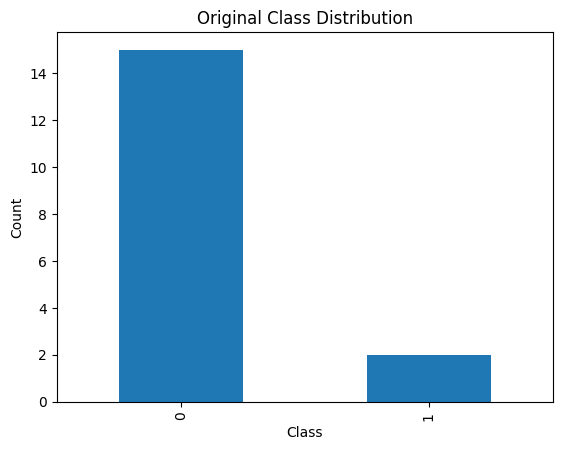

In [ ]:
# 4. Graph

plt.figure()

df["Target"].value_counts().plot(kind='bar')
plt.title("Original Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()